[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/14_busqueda_informada/notebooks/aplicaciones/03_rutas.ipynb)

# Notebook 03: Rutas en una Ciudad — Dijkstra vs A*

En este notebook exploraremos el problema de encontrar rutas óptimas en un grafo sintético de ciudad con **15 nodos**. Compararemos dos algoritmos clásicos de búsqueda informada:

- **Dijkstra**: encuentra el camino más corto desde un origen a todos los demás nodos, sin usar información del destino.
- **A\***: usa una heurística (distancia en línea recta) para guiar la búsqueda de manera más eficiente hacia el destino.

Al finalizar podrás:
1. Construir grafos ponderados y visualizarlos con NetworkX.
2. Implementar Dijkstra y A* desde cero.
3. Comparar el número de nodos expandidos por cada algoritmo.
4. Experimentar con heurísticas alternativas y analizar admisibilidad.

In [1]:
# Instalar dependencias si es necesario (Colab)
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

ensure("networkx")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import networkx as nx
import math
from collections import defaultdict

print("Dependencias listas.")

Dependencias listas.


In [2]:
# ── Estilo y colores ──────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "primary":    "#2563EB",
    "secondary":  "#10B981",
    "accent":     "#F59E0B",
    "danger":     "#EF4444",
    "node":       "#93C5FD",
    "edge":       "#475569",
}

plt.rcParams.update({
    "figure.dpi":       120,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "font.size":        10,
    "legend.fontsize":  9,
})

np.random.seed(42)
print("Estilo configurado.")

Estilo configurado.


---
## Sección 1: El Grafo de la Ciudad

Construiremos un grafo que representa una ciudad sintética con 15 ubicaciones clave. Cada nodo tiene coordenadas $(x, y)$ que usaremos tanto para visualización como para calcular la heurística de distancia en línea recta en A*.

Los pesos de las aristas representan el **costo de viaje** (tiempo o distancia) entre ubicaciones conectadas.

In [3]:
# ── Definición del grafo de la ciudad ────────────────────────────────────────

# Nodos con coordenadas (x, y) — escala arbitraria tipo km
POSICIONES = {
    "Centro":      (5.0, 5.0),
    "Aeropuerto":  (9.5, 8.5),
    "Universidad": (2.0, 8.0),
    "Hospital":    (4.0, 7.0),
    "Estadio":     (8.0, 3.0),
    "Mercado":     (3.5, 3.5),
    "Parque":      (6.5, 6.5),
    "Biblioteca":  (1.5, 5.5),
    "Teatro":      (5.5, 7.5),
    "Estacion":    (7.0, 5.0),
    "Plaza":       (5.0, 2.5),
    "Museo":       (2.5, 6.5),
    "Puerto":      (9.0, 1.5),
    "Fabrica":     (7.5, 7.5),
    "Residencial": (1.0, 2.0),
}

def dist_euclid(a, b):
    """Distancia euclidiana entre dos nodos por nombre."""
    xa, ya = POSICIONES[a]
    xb, yb = POSICIONES[b]
    return math.sqrt((xa - xb)**2 + (ya - yb)**2)

def peso(a, b, variacion=0.0):
    """Peso de arista = dist euclidiana + variacion aleatoria fija."""
    base = dist_euclid(a, b)
    return round(base + variacion, 2)

# Lista de aristas (nodo_a, nodo_b, peso)
ARISTAS_RAW = [
    ("Centro",      "Hospital",    peso("Centro",      "Hospital",    0.3)),
    ("Centro",      "Mercado",     peso("Centro",      "Mercado",     0.2)),
    ("Centro",      "Parque",      peso("Centro",      "Parque",      0.1)),
    ("Centro",      "Estacion",    peso("Centro",      "Estacion",    0.4)),
    ("Centro",      "Plaza",       peso("Centro",      "Plaza",       0.2)),
    ("Centro",      "Teatro",      peso("Centro",      "Teatro",      0.3)),
    ("Aeropuerto",  "Fabrica",     peso("Aeropuerto",  "Fabrica",     0.1)),
    ("Aeropuerto",  "Parque",      peso("Aeropuerto",  "Parque",      0.5)),
    ("Aeropuerto",  "Estacion",    peso("Aeropuerto",  "Estacion",    0.3)),
    ("Universidad", "Hospital",    peso("Universidad", "Hospital",    0.2)),
    ("Universidad", "Biblioteca",  peso("Universidad", "Biblioteca",  0.1)),
    ("Universidad", "Museo",       peso("Universidad", "Museo",       0.3)),
    ("Hospital",    "Teatro",      peso("Hospital",    "Teatro",      0.2)),
    ("Hospital",    "Museo",       peso("Hospital",    "Museo",       0.4)),
    ("Estadio",     "Puerto",      peso("Estadio",     "Puerto",      0.6)),
    ("Estadio",     "Estacion",    peso("Estadio",     "Estacion",    0.2)),
    ("Estadio",     "Plaza",       peso("Estadio",     "Plaza",       0.3)),
    ("Mercado",     "Plaza",       peso("Mercado",     "Plaza",       0.1)),
    ("Mercado",     "Residencial", peso("Mercado",     "Residencial", 0.4)),
    ("Mercado",     "Biblioteca",  peso("Mercado",     "Biblioteca",  0.5)),
    ("Parque",      "Teatro",      peso("Parque",      "Teatro",      0.1)),
    ("Parque",      "Fabrica",     peso("Parque",      "Fabrica",     0.2)),
    ("Biblioteca",  "Residencial", peso("Biblioteca",  "Residencial", 0.3)),
    ("Biblioteca",  "Museo",       peso("Biblioteca",  "Museo",       0.2)),
    ("Estacion",    "Fabrica",     peso("Estacion",    "Fabrica",     0.3)),
    ("Puerto",      "Fabrica",     peso("Puerto",      "Fabrica",     0.8)),
    ("Plaza",       "Residencial", peso("Plaza",       "Residencial", 0.5)),
]

# Construir el grafo como diccionario de adyacencia
GRAFO = defaultdict(dict)
for u, v, w in ARISTAS_RAW:
    GRAFO[u][v] = w
    GRAFO[v][u] = w

NODOS = list(POSICIONES.keys())
print(f"Nodos: {len(NODOS)}")
print(f"Aristas: {len(ARISTAS_RAW)}")
print("\nVecinos del Centro:", dict(GRAFO["Centro"]))

Nodos: 15
Aristas: 27

Vecinos del Centro: {'Hospital': 2.54, 'Mercado': 2.32, 'Parque': 2.22, 'Estacion': 2.4, 'Plaza': 2.7, 'Teatro': 2.85}


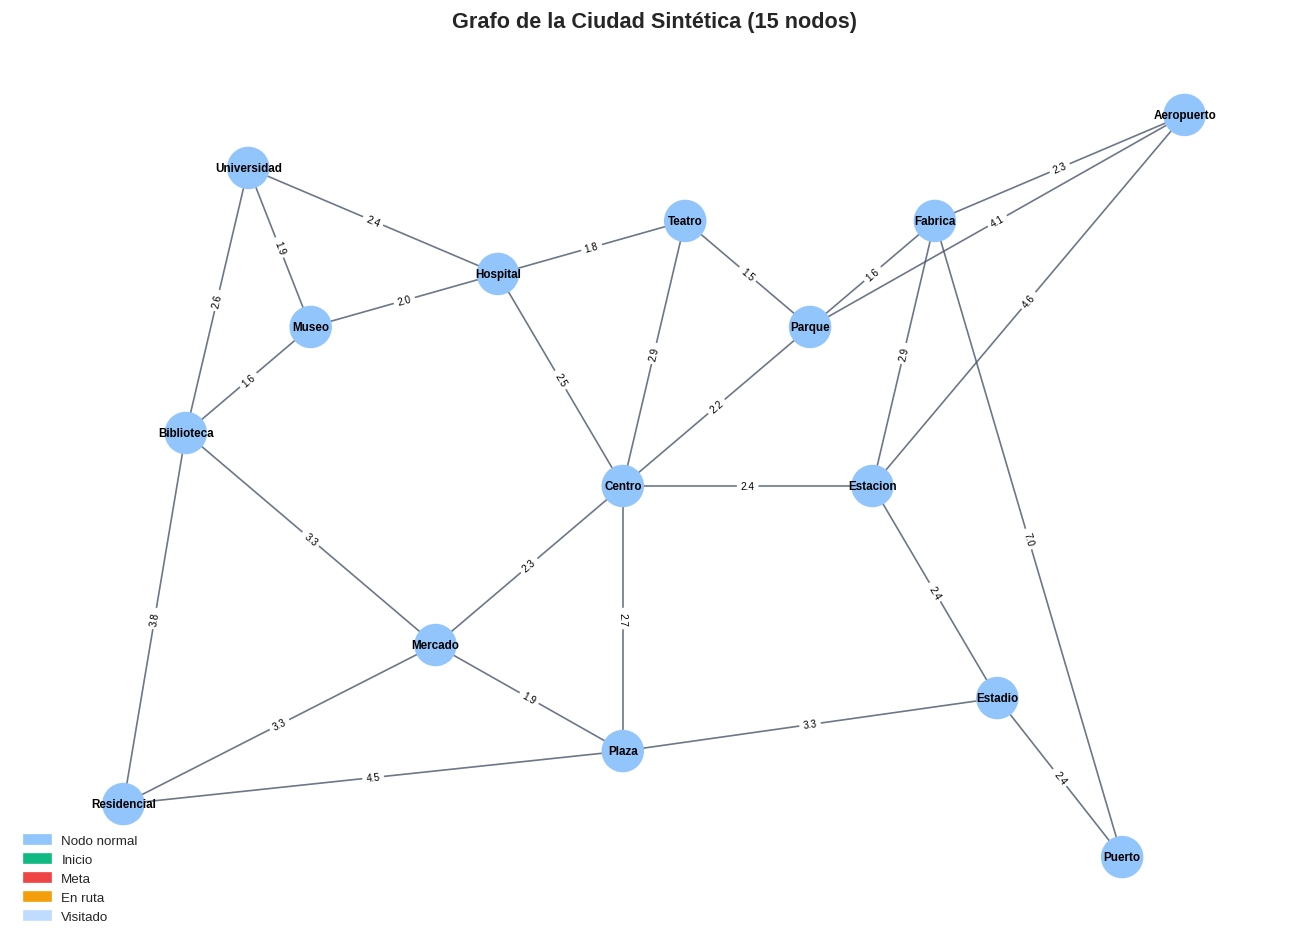


Grafo conexo: True


In [4]:
# ── Visualización del grafo completo ─────────────────────────────────────────

def construir_nx_grafo(aristas=None):
    """Construye un grafo NetworkX a partir de ARISTAS_RAW o aristas personalizadas."""
    G = nx.Graph()
    G.add_nodes_from(NODOS)
    for u, v, w in (aristas or ARISTAS_RAW):
        G.add_edge(u, v, weight=w)
    return G

def visualizar_grafo(G, titulo="Grafo de la Ciudad",
                     nodos_visitados=None, ruta=None,
                     inicio=None, meta=None,
                     aristas_resaltadas=None, ax=None):
    """
    Visualiza el grafo con opciones para resaltar rutas y nodos visitados.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 8))
    else:
        fig = ax.figure

    pos = POSICIONES

    # Colores de nodos
    color_nodos = []
    for n in G.nodes():
        if n == inicio:
            color_nodos.append(COLORS["secondary"])
        elif n == meta:
            color_nodos.append(COLORS["danger"])
        elif ruta and n in ruta:
            color_nodos.append(COLORS["accent"])
        elif nodos_visitados and n in nodos_visitados:
            color_nodos.append("#BFDBFE")  # azul claro
        else:
            color_nodos.append(COLORS["node"])

    # Aristas
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        if aristas_resaltadas and ((u, v) in aristas_resaltadas or (v, u) in aristas_resaltadas):
            edge_colors.append(COLORS["accent"])
            edge_widths.append(3.5)
        elif ruta and len(ruta) > 1:
            pares_ruta = set(zip(ruta, ruta[1:]))
            if (u, v) in pares_ruta or (v, u) in pares_ruta:
                edge_colors.append(COLORS["primary"])
                edge_widths.append(3.5)
            else:
                edge_colors.append(COLORS["edge"])
                edge_widths.append(1.0)
        else:
            edge_colors.append(COLORS["edge"])
            edge_widths.append(1.0)

    nx.draw_networkx_nodes(G, pos, node_color=color_nodos,
                           node_size=600, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors,
                           width=edge_widths, alpha=0.8, ax=ax)

    pesos_labels = nx.get_edge_attributes(G, "weight")
    pesos_str = {k: f"{v:.1f}" for k, v in pesos_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=pesos_str,
                                  font_size=6, ax=ax)

    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.axis("off")

    # Leyenda
    leyenda = [
        mpatches.Patch(color=COLORS["node"],      label="Nodo normal"),
        mpatches.Patch(color=COLORS["secondary"],  label="Inicio"),
        mpatches.Patch(color=COLORS["danger"],     label="Meta"),
        mpatches.Patch(color=COLORS["accent"],     label="En ruta"),
        mpatches.Patch(color="#BFDBFE",            label="Visitado"),
    ]
    ax.legend(handles=leyenda, loc="lower left", fontsize=8)
    return fig, ax

G_ciudad = construir_nx_grafo()
fig, ax = visualizar_grafo(G_ciudad, titulo="Grafo de la Ciudad Sintética (15 nodos)")
plt.tight_layout()
plt.show()
print(f"\nGrafo conexo: {nx.is_connected(G_ciudad)}")

---
## Sección 2: Dijkstra — Rutas Mínimas desde el Centro

El algoritmo de Dijkstra encuentra el **camino más corto** desde un nodo origen a **todos los demás nodos** del grafo. Opera de forma greedy: siempre expande el nodo con menor costo acumulado.

**Complejidad:** $O((V + E) \log V)$ con heap binario.

**Limitación:** No usa información del destino, por lo que explora en todas las direcciones.

In [5]:
# ── Implementación de Dijkstra ────────────────────────────────────────────────

def dijkstra(grafo, inicio):
    """
    Dijkstra desde `inicio` hacia todos los nodos.

    Retorna:
      distancias : dict nodo -> costo mínimo
      previos    : dict nodo -> nodo anterior en el camino óptimo
      expandidos : list de nodos en orden de expansión
    """
    distancias = {n: float('inf') for n in grafo}
    distancias[inicio] = 0.0
    previos = {n: None for n in grafo}
    expandidos = []

    # heap: (costo, nodo)
    heap = [(0.0, inicio)]

    visitados = set()

    while heap:
        costo, nodo = heapq.heappop(heap)

        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos.append(nodo)

        for vecino, peso in grafo[nodo].items():
            nuevo_costo = costo + peso
            if nuevo_costo < distancias[vecino]:
                distancias[vecino] = nuevo_costo
                previos[vecino] = nodo
                heapq.heappush(heap, (nuevo_costo, vecino))

    return distancias, previos, expandidos


def reconstruir_camino(previos, origen, destino):
    """Reconstruye el camino óptimo usando el diccionario de previos."""
    camino = []
    nodo = destino
    while nodo is not None:
        camino.append(nodo)
        nodo = previos.get(nodo)
    camino.reverse()
    if camino[0] != origen:
        return []  # no hay camino
    return camino


# Ejecutar Dijkstra desde el Centro
dist_centro, prev_centro, exp_centro = dijkstra(GRAFO, "Centro")

print("Dijkstra ejecutado desde: Centro")
print(f"Nodos expandidos: {len(exp_centro)}")
print(f"Orden de expansión: {exp_centro}")

Dijkstra ejecutado desde: Centro
Nodos expandidos: 15
Orden de expansión: ['Centro', 'Parque', 'Mercado', 'Estacion', 'Hospital', 'Plaza', 'Teatro', 'Fabrica', 'Museo', 'Estadio', 'Universidad', 'Residencial', 'Biblioteca', 'Aeropuerto', 'Puerto']


In [6]:
# ── Tabla de distancias desde el Centro ──────────────────────────────────────

print(f"{'Destino':<15} {'Distancia':>12}  Camino")
print("-" * 60)
for nodo in sorted(dist_centro, key=lambda n: dist_centro[n]):
    if nodo == "Centro":
        continue
    camino = reconstruir_camino(prev_centro, "Centro", nodo)
    camino_str = " → ".join(camino)
    print(f"{nodo:<15} {dist_centro[nodo]:>12.2f}  {camino_str}")

Destino            Distancia  Camino
------------------------------------------------------------
Parque                  2.22  Centro → Parque
Mercado                 2.32  Centro → Mercado
Estacion                2.40  Centro → Estacion
Hospital                2.54  Centro → Hospital
Plaza                   2.70  Centro → Plaza
Teatro                  2.85  Centro → Teatro
Fabrica                 3.83  Centro → Parque → Fabrica
Museo                   4.52  Centro → Hospital → Museo
Estadio                 4.84  Centro → Estacion → Estadio
Universidad             4.98  Centro → Hospital → Universidad
Residencial             5.64  Centro → Mercado → Residencial
Biblioteca              5.65  Centro → Mercado → Biblioteca
Aeropuerto              6.17  Centro → Parque → Fabrica → Aeropuerto
Puerto                  7.24  Centro → Estacion → Estadio → Puerto


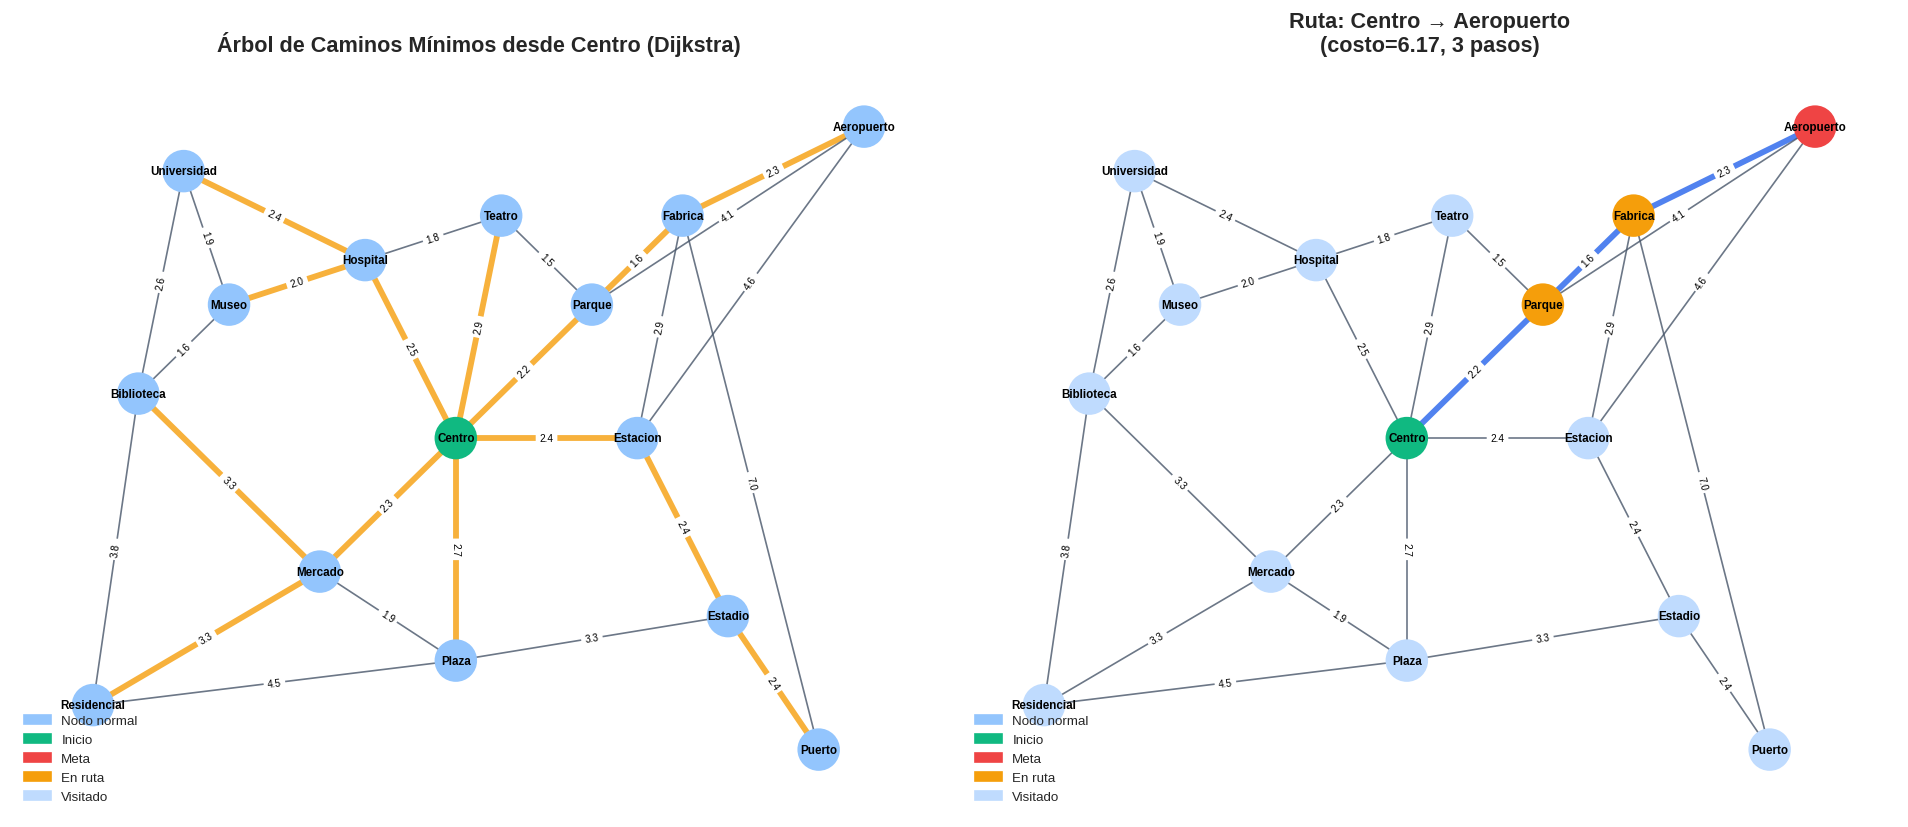

In [7]:
# ── Árbol de caminos mínimos desde el Centro ─────────────────────────────────

# Aristas del árbol de caminos mínimos
aristas_arbol = set()
for nodo, prev in prev_centro.items():
    if prev is not None:
        aristas_arbol.add((prev, nodo))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Izquierda: árbol de caminos mínimos
visualizar_grafo(
    G_ciudad,
    titulo="Árbol de Caminos Mínimos desde Centro (Dijkstra)",
    inicio="Centro",
    aristas_resaltadas=aristas_arbol,
    ax=axes[0]
)

# Derecha: ruta específica Centro → Aeropuerto
ruta_aero = reconstruir_camino(prev_centro, "Centro", "Aeropuerto")
visitados_aero = set(exp_centro)  # Dijkstra expande todos
visualizar_grafo(
    G_ciudad,
    titulo=f"Ruta: Centro → Aeropuerto\n(costo={dist_centro['Aeropuerto']:.2f}, {len(ruta_aero)-1} pasos)",
    nodos_visitados=visitados_aero,
    ruta=ruta_aero,
    inicio="Centro",
    meta="Aeropuerto",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

---
## Sección 3: A* con Heurística de Línea Recta

A* mejora sobre Dijkstra usando una **función de evaluación**:

$$f(n) = g(n) + h(n)$$

donde:
- $g(n)$ = costo acumulado desde el inicio hasta $n$
- $h(n)$ = heurística: estimación del costo de $n$ hasta la meta

Usamos la **distancia euclidiana** como heurística:

$$h(n) = \sqrt{(x_n - x_{meta})^2 + (y_n - y_{meta})^2}$$

Esta heurística es **admisible** porque nunca sobreestima el costo real (la línea recta es el camino más corto posible).

In [8]:
# ── Implementación de A* ──────────────────────────────────────────────────────

def heuristica_euclidiana(nodo, meta):
    """h(n) = distancia euclidiana en línea recta hasta la meta."""
    return dist_euclid(nodo, meta)


def a_star(grafo, inicio, meta, h=heuristica_euclidiana):
    """
    A* desde `inicio` hasta `meta`.

    Retorna:
      camino     : lista de nodos del camino óptimo (o [] si no existe)
      costo      : costo total del camino
      expandidos : lista de nodos expandidos en orden
    """
    # heap: (f, g, nodo)
    heap = [(h(inicio, meta), 0.0, inicio)]
    g_costs = {inicio: 0.0}
    previos = {inicio: None}
    visitados = set()
    expandidos = []

    while heap:
        f, g, nodo = heapq.heappop(heap)

        if nodo in visitados:
            continue
        visitados.add(nodo)
        expandidos.append(nodo)

        if nodo == meta:
            # Reconstruir camino
            camino = []
            n = meta
            while n is not None:
                camino.append(n)
                n = previos[n]
            camino.reverse()
            return camino, g, expandidos

        for vecino, peso in grafo[nodo].items():
            nuevo_g = g + peso
            if vecino not in g_costs or nuevo_g < g_costs[vecino]:
                g_costs[vecino] = nuevo_g
                previos[vecino] = nodo
                f_nuevo = nuevo_g + h(vecino, meta)
                heapq.heappush(heap, (f_nuevo, nuevo_g, vecino))

    return [], float('inf'), expandidos


# Comparar Dijkstra vs A* en 3 rutas específicas
RUTAS_TEST = [
    ("Centro",      "Aeropuerto"),
    ("Universidad", "Puerto"),
    ("Estadio",     "Museo"),
]

print(f"{'Ruta':<30} {'Algo':<10} {'Costo':>8} {'Expandidos':>12}  Camino")
print("-" * 90)

resultados_comparacion = []

for origen, destino in RUTAS_TEST:
    # Dijkstra
    dist_d, prev_d, exp_d = dijkstra(GRAFO, origen)
    camino_d = reconstruir_camino(prev_d, origen, destino)
    costo_d  = dist_d[destino]
    # Para Dijkstra, contamos nodos hasta que se expande el destino
    exp_d_hasta_meta = exp_d[:exp_d.index(destino) + 1] if destino in exp_d else exp_d

    # A*
    camino_a, costo_a, exp_a = a_star(GRAFO, origen, destino)

    resultados_comparacion.append({
        "ruta":       f"{origen} → {destino}",
        "costo_d":    costo_d,
        "exp_dijkstra": len(exp_d_hasta_meta),
        "costo_a":    costo_a,
        "exp_astar":  len(exp_a),
        "camino":     camino_a,
        "visitados_a": set(exp_a),
    })

    nombre_ruta = f"{origen} → {destino}"
    print(f"{nombre_ruta:<30} {'Dijkstra':<10} {costo_d:>8.2f} {len(exp_d_hasta_meta):>12}  {' → '.join(camino_d)}")
    print(f"{'':<30} {'A*':<10} {costo_a:>8.2f} {len(exp_a):>12}  {' → '.join(camino_a)}")
    print()

Ruta                           Algo          Costo   Expandidos  Camino
------------------------------------------------------------------------------------------
Centro → Aeropuerto            Dijkstra       6.17           14  Centro → Parque → Fabrica → Aeropuerto
                               A*             6.17            4  Centro → Parque → Fabrica → Aeropuerto

Universidad → Puerto           Dijkstra      12.22           15  Universidad → Hospital → Centro → Estacion → Estadio → Puerto
                               A*            12.22           12  Universidad → Hospital → Centro → Estacion → Estadio → Puerto

Estadio → Museo                Dijkstra       9.36           14  Estadio → Estacion → Centro → Hospital → Museo
                               A*             9.36            7  Estadio → Estacion → Centro → Hospital → Museo



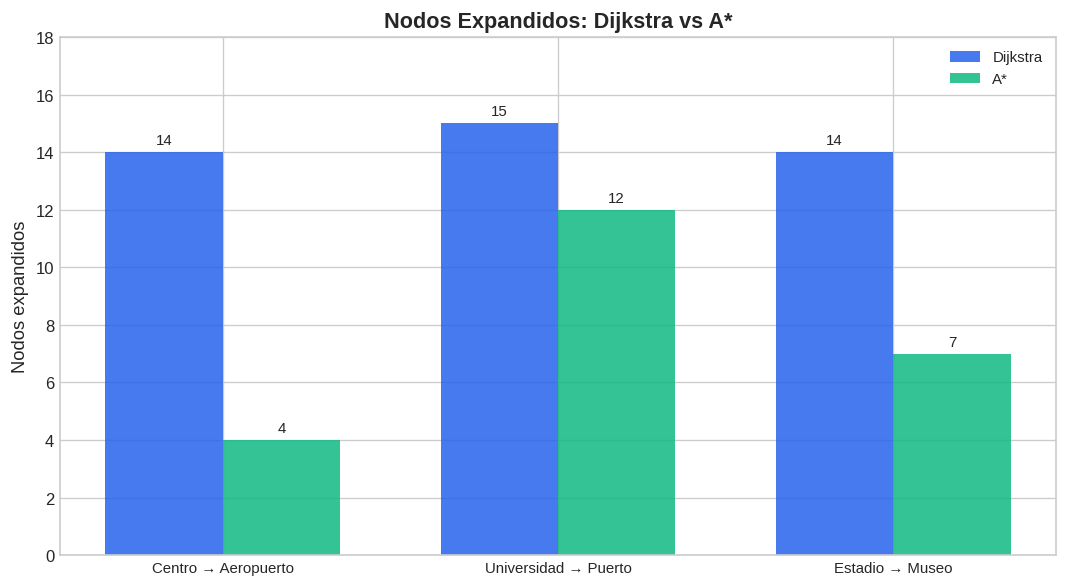

In [9]:
# ── Gráfica comparativa de nodos expandidos ───────────────────────────────────

rutas_labels = [r["ruta"] for r in resultados_comparacion]
exp_dijk = [r["exp_dijkstra"] for r in resultados_comparacion]
exp_ast  = [r["exp_astar"]   for r in resultados_comparacion]

x = np.arange(len(rutas_labels))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_d = ax.bar(x - ancho/2, exp_dijk, ancho, label="Dijkstra",
                   color=COLORS["primary"], alpha=0.85)
barras_a = ax.bar(x + ancho/2, exp_ast,  ancho, label="A*",
                   color=COLORS["secondary"], alpha=0.85)

ax.bar_label(barras_d, padding=3, fontsize=9)
ax.bar_label(barras_a, padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(rutas_labels, fontsize=9)
ax.set_ylabel("Nodos expandidos")
ax.set_title("Nodos Expandidos: Dijkstra vs A*", fontweight="bold")
ax.legend()
ax.set_ylim(0, max(exp_dijk + exp_ast) + 3)

plt.tight_layout()
plt.show()

---
## Sección 4: Visualización de Rutas

Visualizamos las tres rutas de prueba mostrando:
- **Nodos explorados** (azul claro): todos los nodos que A* consideró
- **Ruta óptima** (línea azul gruesa): el camino encontrado
- **Inicio** (verde) y **Meta** (rojo)

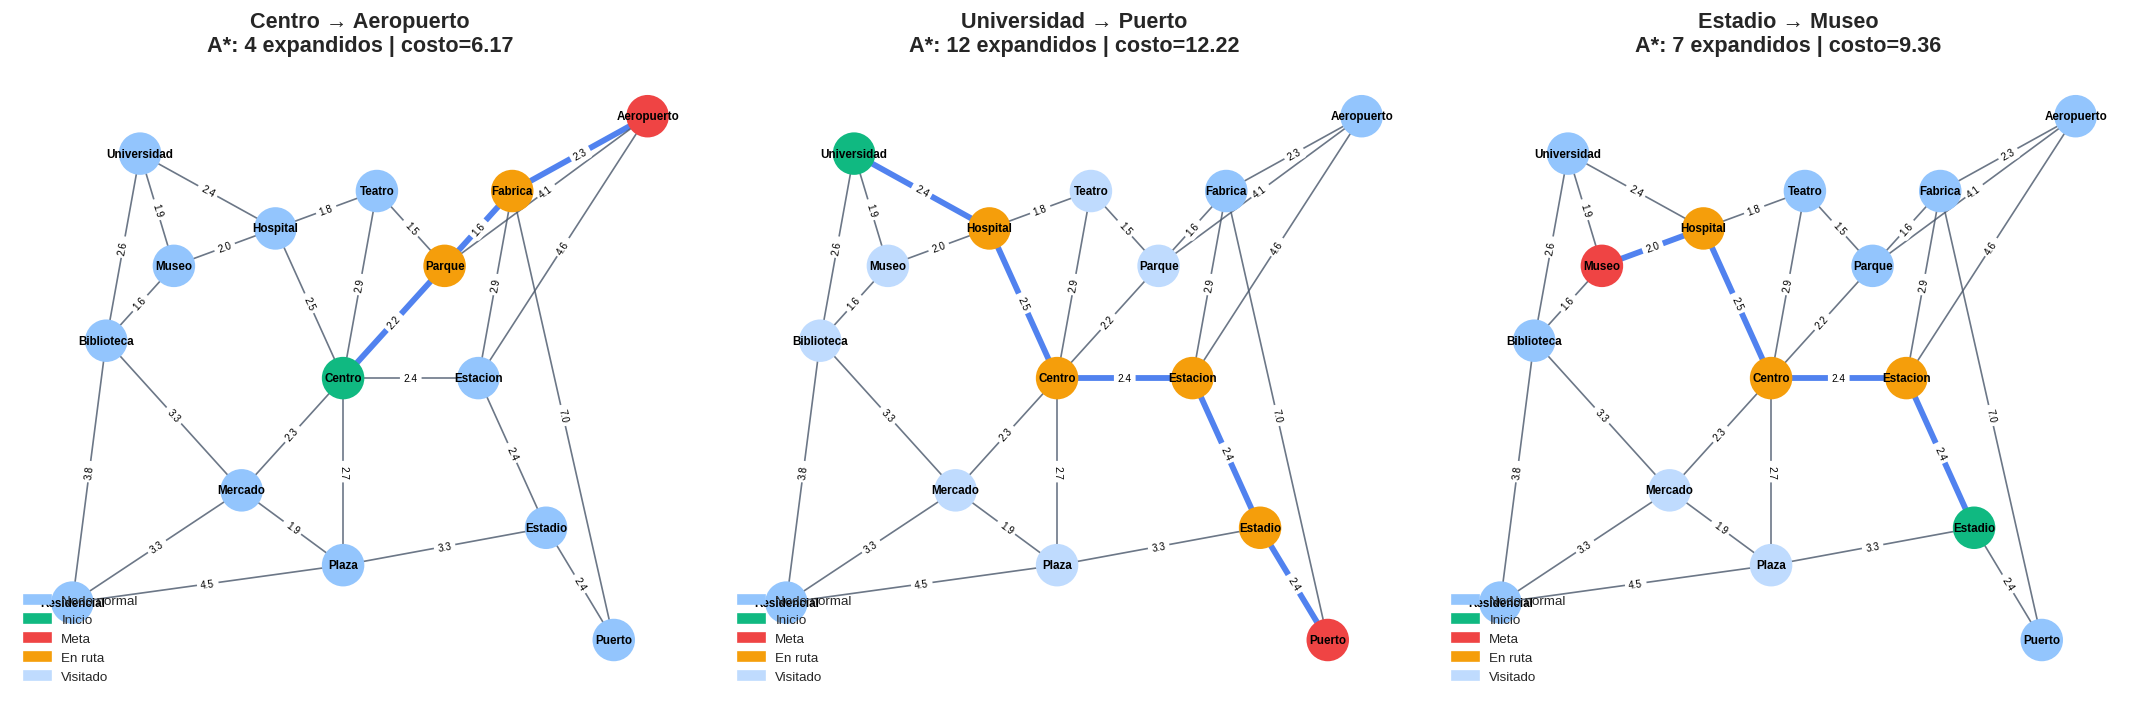

In [10]:
# ── Visualización de las 3 rutas ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, res in enumerate(resultados_comparacion):
    origen, destino = res["ruta"].split(" → ")
    visualizar_grafo(
        G_ciudad,
        titulo=f"{res['ruta']}\nA*: {res['exp_astar']} expandidos | costo={res['costo_a']:.2f}",
        nodos_visitados=res["visitados_a"],
        ruta=res["camino"],
        inicio=origen,
        meta=destino,
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

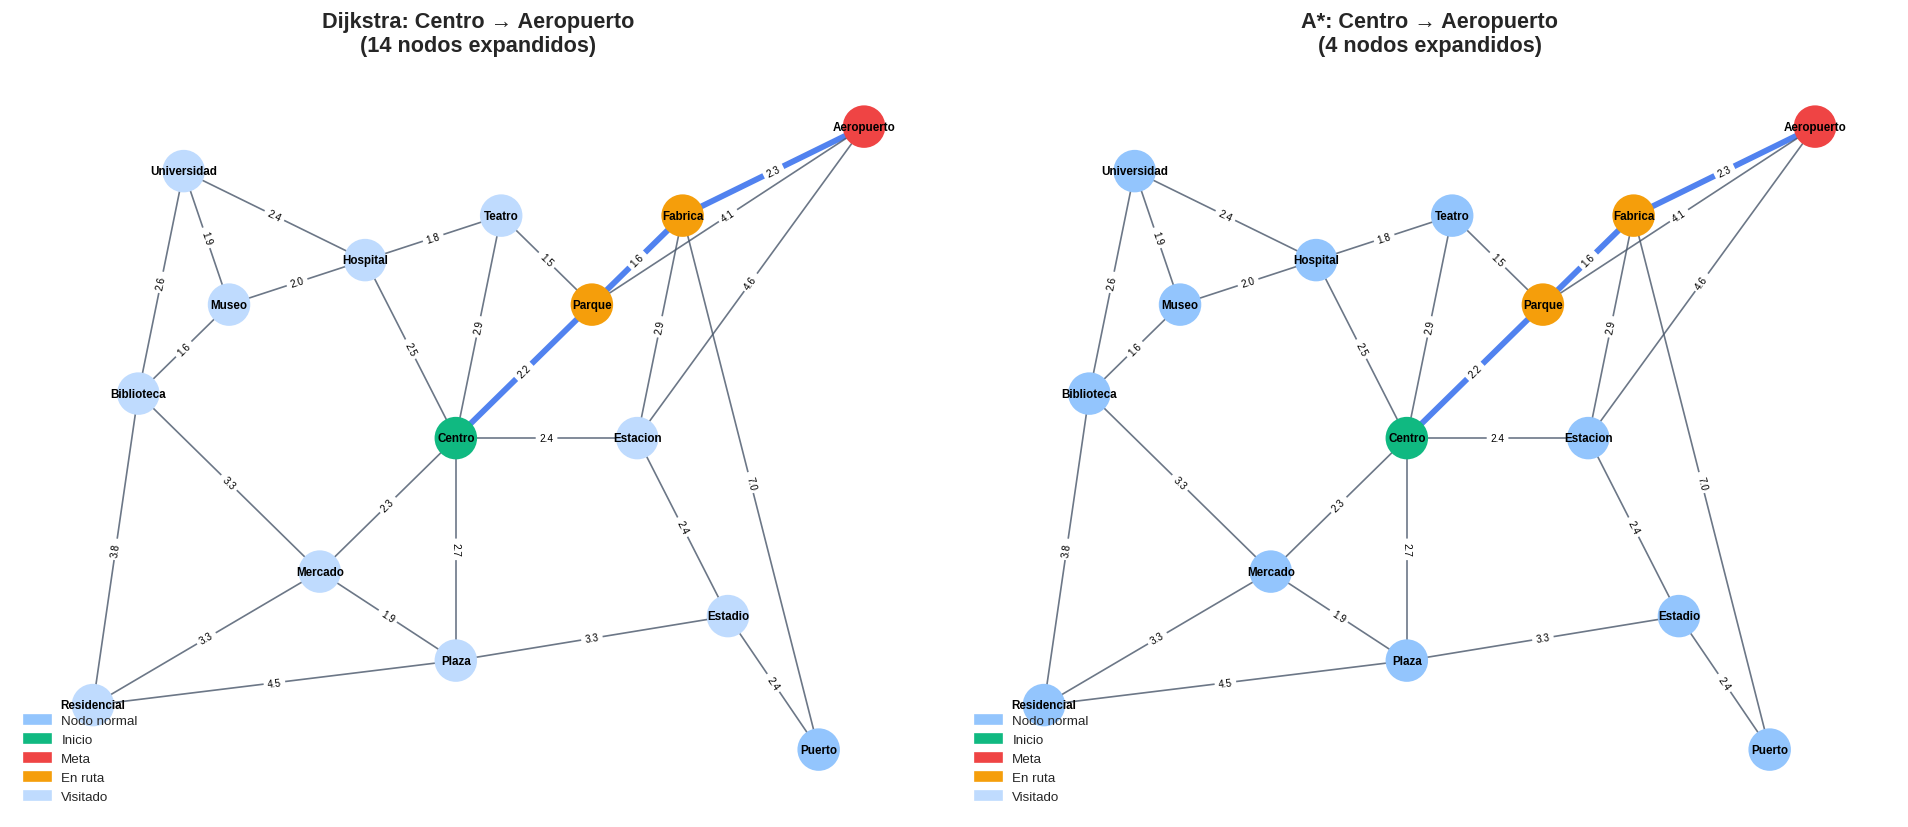

In [11]:
# ── Comparación visual Dijkstra vs A* en Centro → Aeropuerto ─────────────────

origen, destino = "Centro", "Aeropuerto"

# Dijkstra
dist_d, prev_d, exp_d = dijkstra(GRAFO, origen)
camino_d = reconstruir_camino(prev_d, origen, destino)
exp_d_hasta = set(exp_d[:exp_d.index(destino) + 1])

# A*
camino_a, _, exp_a = a_star(GRAFO, origen, destino)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

visualizar_grafo(
    G_ciudad,
    titulo=f"Dijkstra: {origen} → {destino}\n({len(exp_d_hasta)} nodos expandidos)",
    nodos_visitados=exp_d_hasta,
    ruta=camino_d,
    inicio=origen,
    meta=destino,
    ax=axes[0]
)

visualizar_grafo(
    G_ciudad,
    titulo=f"A*: {origen} → {destino}\n({len(exp_a)} nodos expandidos)",
    nodos_visitados=set(exp_a),
    ruta=camino_a,
    inicio=origen,
    meta=destino,
    ax=axes[1]
)

plt.tight_layout()
plt.show()

---
## Ejercicio 1

**Encuentra las 3 rutas más largas entre pares de nodos. ¿En cuáles de estas rutas A\* expande significativamente menos nodos que Dijkstra? ¿Por qué?**

Pistas:
- Itera sobre todos los pares de nodos $(u, v)$ con $u \neq v$.
- Usa A\* para encontrar el costo de cada ruta.
- Ordena de mayor a menor y toma los 3 primeros pares.
- Compara nodos expandidos por A\* y Dijkstra en esos pares.
- Reflexiona: ¿Cómo influye la geometría del grafo en la eficiencia de A\*?

Ruta                                  Costo   Dijk exp   A* exp   Ahorro
------------------------------------------------------------------------
Universidad → Puerto                  12.22         15       12       +3
Puerto → Universidad                  12.22         15        7       +8
Aeropuerto → Residencial              11.81         15        7       +8

Observacion: A* ahorra mas nodos en rutas largas donde origen y destino
estan en extremos opuestos del mapa — la heuristica euclidiana descarta
nodos que se alejan geometricamente de la meta.


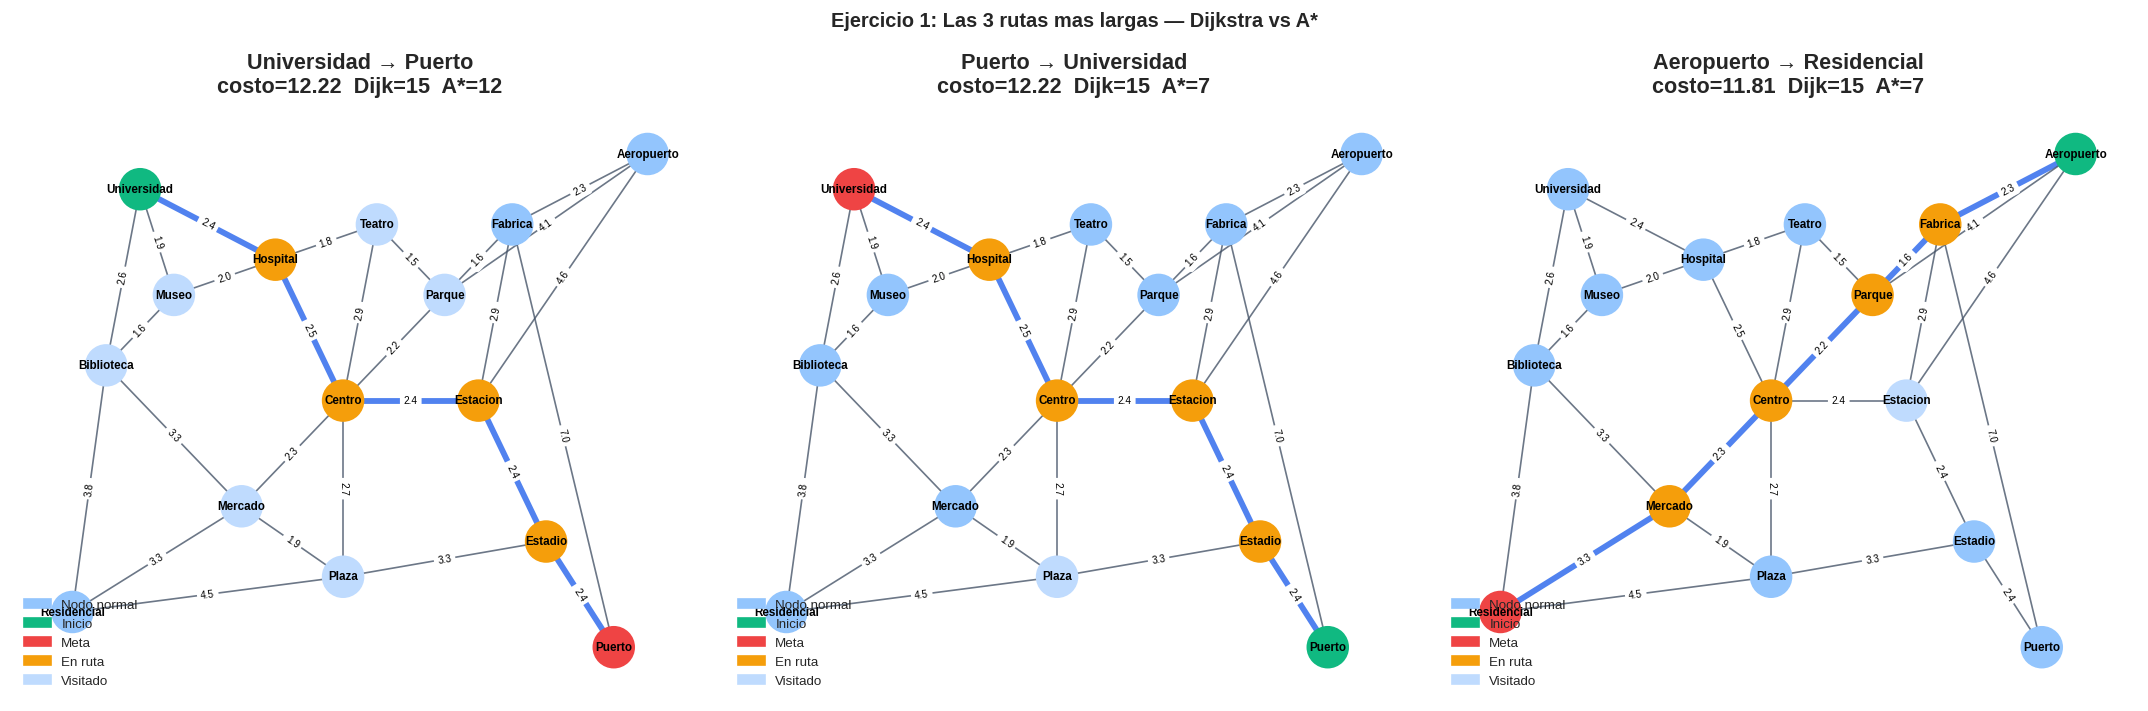

In [12]:
# ── Ejercicio 1 ───────────────────────────────────────────────────────────────
# Tu código aquí

# Paso 1: Encuentra todos los costos de ruta entre pares de nodos
todos_pares = []
for u in NODOS:
    for v in NODOS:
        if u != v:
            camino_a, costo_a, exp_a = a_star(GRAFO, u, v)
            if costo_a < float('inf'):
                todos_pares.append((u, v, costo_a))

# Paso 2: Ordenar por costo y tomar los 3 más largos
todos_pares.sort(key=lambda x: -x[2])
top3 = todos_pares[:3]

# Paso 3: Comparar nodos expandidos Dijkstra vs A* en esos 3 pares
print(f"{'Ruta':<35} {'Costo':>7}  {'Dijk exp':>9}  {'A* exp':>7}  {'Ahorro':>7}")
print("-" * 72)
resultados_top3 = []
for u, v, costo in top3:
    dist_d, prev_d, exp_d = dijkstra(GRAFO, u)
    n_dijk = len(exp_d[:exp_d.index(v) + 1]) if v in exp_d else len(exp_d)
    camino_a, costo_a, exp_a = a_star(GRAFO, u, v)
    n_astar = len(exp_a)
    ahorro = n_dijk - n_astar
    print(f"{u+' → '+v:<35} {costo:>7.2f}  {n_dijk:>9}  {n_astar:>7}  {ahorro:>+7}")
    resultados_top3.append((u, v, costo, n_dijk, n_astar, camino_a, set(exp_a), prev_d))

print()
print("Observacion: A* ahorra mas nodos en rutas largas donde origen y destino")
print("estan en extremos opuestos del mapa — la heuristica euclidiana descarta")
print("nodos que se alejan geometricamente de la meta.")

# Paso 4: Visualizar las 3 rutas con visualizar_grafo del notebook
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (u, v, costo, n_dijk, n_astar, camino_a, vis_a, prev_d) in zip(axes, resultados_top3):
    visualizar_grafo(
        G_ciudad,
        titulo=f"{u} → {v}\ncosto={costo:.2f}  Dijk={n_dijk}  A*={n_astar}",
        nodos_visitados=vis_a,
        ruta=camino_a,
        inicio=u,
        meta=v,
        ax=ax
    )
plt.suptitle('Ejercicio 1: Las 3 rutas mas largas — Dijkstra vs A*', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Ejercicio 2

**Simula un 'embotellamiento': duplica el peso de 3 aristas que forman una ruta muy usada. Recalcula las rutas más cortas. ¿Qué rutas cambiaron?**

Pistas:
- Identifica las aristas más frecuentes en los caminos óptimos desde el Centro (o en todas las rutas óptimas).
- Duplica los pesos de esas 3 aristas.
- Recalcula Dijkstra desde el Centro.
- Compara las distancias y caminos antes/después del embotellamiento.

Aristas mas usadas en rutas optimas desde Centro:
  Centro <-> Parque: usada en 3 rutas  (peso=2.22 -> embotellado=4.44)
  Centro <-> Hospital: usada en 3 rutas  (peso=2.54 -> embotellado=5.08)
  Centro <-> Estacion: usada en 3 rutas  (peso=2.40 -> embotellado=4.80)

Destino           Original  Embotellado   Cambio  Ruta cambio?
------------------------------------------------------------
Aeropuerto            6.17         8.31    +2.14  True  <- DESVIO
Biblioteca            5.65         5.65    +0.00  False
Estacion              2.40         4.80    +2.40  False
Estadio               4.84         6.04    +1.20  True  <- DESVIO
Fabrica               3.83         5.97    +2.14  True  <- DESVIO
Hospital              2.54         4.63    +2.09  True  <- DESVIO
Mercado               2.32         2.32    +0.00  False
Museo                 4.52         6.61    +2.09  True  <- DESVIO
Parque                2.22         4.36    +2.14  True  <- DESVIO
Plaza                 2.70         2.70    +

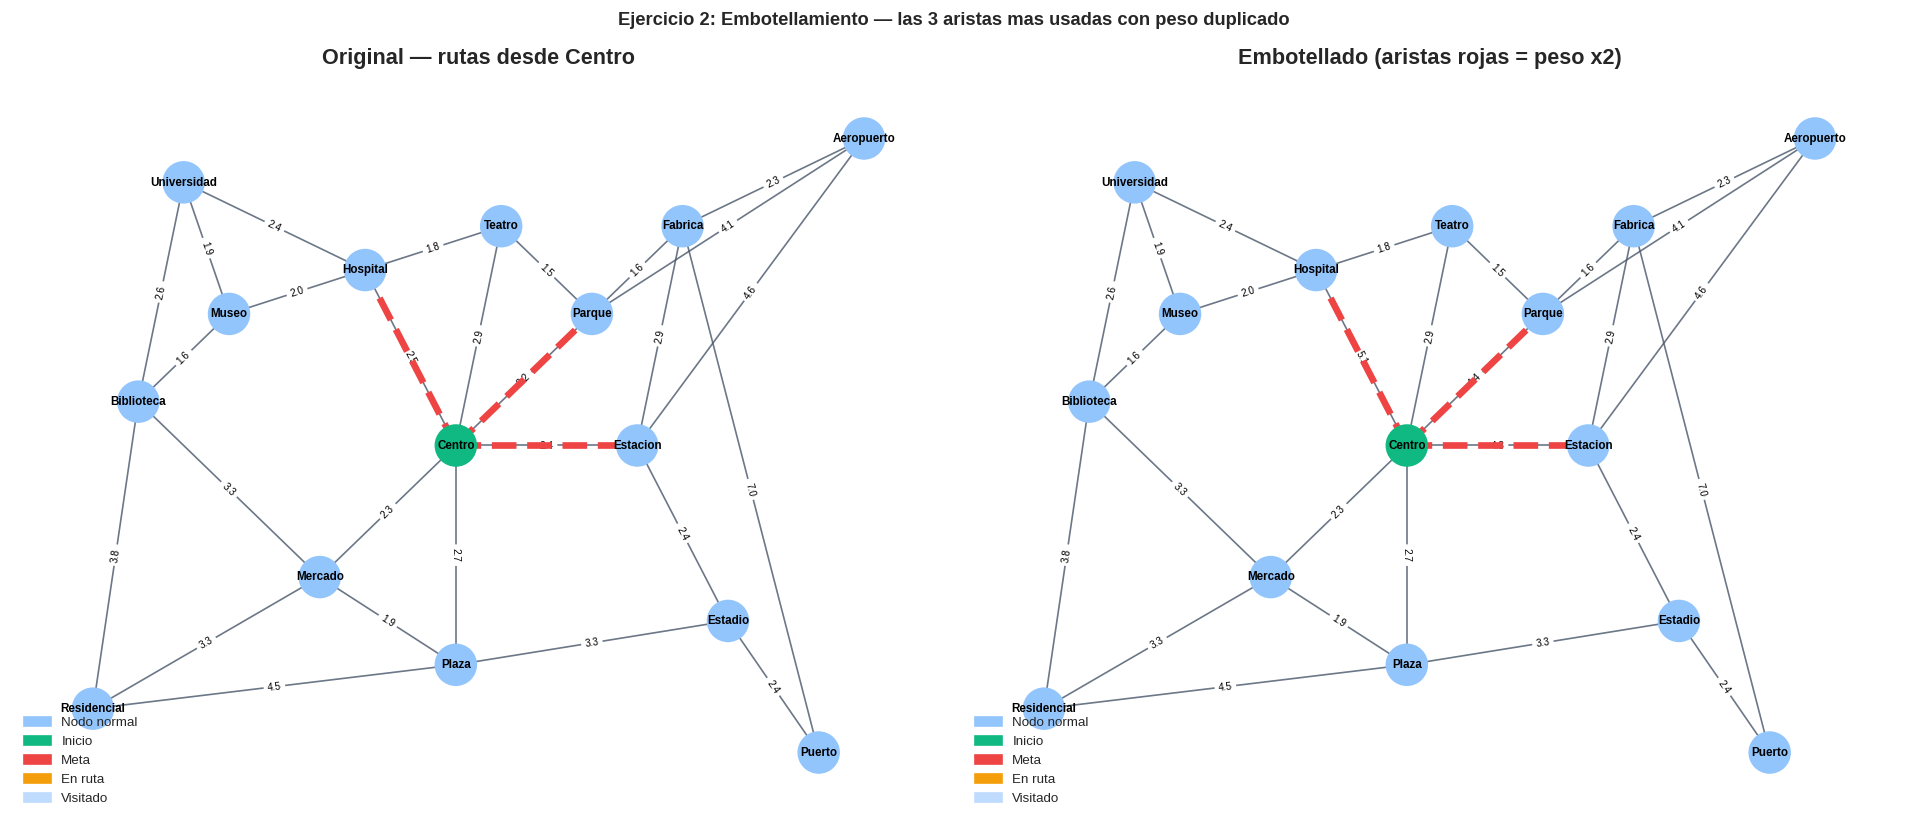

In [13]:
# ── Ejercicio 2 ───────────────────────────────────────────────────────────────
from collections import Counter

# Paso 1: Identificar las aristas mas frecuentes en caminos optimos desde Centro
contador_aristas = Counter()
dist_base, prev_base, _ = dijkstra(GRAFO, "Centro")

for nodo in NODOS:
    if nodo == "Centro":
        continue
    camino = reconstruir_camino(prev_base, "Centro", nodo)
    for i in range(len(camino) - 1):
        arista = tuple(sorted([camino[i], camino[i+1]]))
        contador_aristas[arista] += 1

top3_aristas = [a for a, _ in contador_aristas.most_common(3)]
top3_set = set(top3_aristas)
print("Aristas mas usadas en rutas optimas desde Centro:")
for arista, cnt in contador_aristas.most_common(3):
    w_orig = GRAFO[arista[0]][arista[1]]
    print(f"  {arista[0]} <-> {arista[1]}: usada en {cnt} rutas  (peso={w_orig:.2f} -> embotellado={w_orig*2:.2f})")

# Paso 2: Construir grafo embotellado
ARISTAS_EMBOT = [(u, v, w*2 if tuple(sorted([u, v])) in top3_set else w)
                 for u, v, w in ARISTAS_RAW]
GRAFO_EMBOT = defaultdict(dict)
for u, v, w in ARISTAS_EMBOT:
    GRAFO_EMBOT[u][v] = w
    GRAFO_EMBOT[v][u] = w

# Paso 3: Dijkstra en grafo embotellado
dist_emb, prev_emb, _ = dijkstra(GRAFO_EMBOT, "Centro")

# Paso 4: Comparar distancias
print(f"\n{'Destino':<15} {'Original':>10} {'Embotellado':>12} {'Cambio':>8}  Ruta cambio?")
print("-" * 60)
rutas_cambiadas = []
for nodo in sorted(NODOS):
    if nodo == "Centro": continue
    d_orig = dist_base[nodo]
    d_emb  = dist_emb[nodo]
    cam_orig = reconstruir_camino(prev_base, "Centro", nodo)
    cam_emb  = reconstruir_camino(prev_emb,  "Centro", nodo)
    cambio = cam_orig != cam_emb
    if cambio: rutas_cambiadas.append(nodo)
    marker = '  <- DESVIO' if cambio else ''
    print(f"{nodo:<15} {d_orig:>10.2f} {d_emb:>12.2f} {d_emb-d_orig:>+8.2f}  {str(cambio)}{marker}")

print(f"\nTotal rutas con desvio: {len(rutas_cambiadas)} -> {rutas_cambiadas}")

# Paso 5: Visualizar antes/despues
G_embot = construir_nx_grafo(ARISTAS_EMBOT)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Grafo original
visualizar_grafo(G_ciudad, titulo='Original — rutas desde Centro',
                 inicio='Centro', ax=axes[0])
# Marcar aristas embotelladas en rojo encima
pos_emb = POSICIONES
aristas_embot_list = [(a, b) for a, b in [(a[0],a[1]) for a in top3_aristas]]
nx.draw_networkx_edges(G_ciudad, pos=pos_emb, ax=axes[0],
                       edgelist=aristas_embot_list,
                       edge_color=COLORS['danger'], width=4, style='dashed')

# Grafo embotellado
visualizar_grafo(G_embot, titulo='Embotellado (aristas rojas = peso x2)',
                 inicio='Centro', ax=axes[1])
nx.draw_networkx_edges(G_embot, pos=pos_emb, ax=axes[1],
                       edgelist=aristas_embot_list,
                       edge_color=COLORS['danger'], width=4, style='dashed')

plt.suptitle('Ejercicio 2: Embotellamiento — las 3 aristas mas usadas con peso duplicado',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Ejercicio 3

**Diseña una heurística alternativa:**

$$h_{manhattan}(n) = 0.5 \times (|x_n - x_{meta}| + |y_n - y_{meta}|)$$

Compara con la heurística euclidiana. ¿Cuál es más **informativa** (más cerca del costo real)? ¿Sigue siendo **admisible**?

Recuerda: una heurística es admisible si $h(n) \leq h^*(n)$ para todo nodo $n$, donde $h^*(n)$ es el costo real hasta la meta.

Pistas:
- Implementa `heuristica_manhattan_escalada(nodo, meta)`.
- Ejecuta A\* con ambas heurísticas en las mismas rutas.
- Compara nodos expandidos: una heurística más informativa → menos nodos expandidos.
- Para verificar admisibilidad, compara $h(n)$ contra el costo real desde $n$ hasta la meta.

Ruta                           Heuristica            Expandidos    Costo
------------------------------------------------------------------------
Centro -> Aeropuerto           Euclidiana                     4     6.17
                               Manhattan x0.5                 7     6.17

Universidad -> Puerto          Euclidiana                    12    12.22
                               Manhattan x0.5                14    12.22

Estadio -> Museo               Euclidiana                     7     9.36
                               Manhattan x0.5                10     9.36

Verificacion de admisibilidad — h(n) <= h*(n) para todo nodo n:
Meta              Viol. Euclidiana   Viol. Manhattan
----------------------------------------------------
Aeropuerto            OK (0 viol.)      OK (0 viol.)
Biblioteca            OK (0 viol.)      OK (0 viol.)
Centro                OK (0 viol.)      OK (0 viol.)
Estacion              OK (0 viol.)      OK (0 viol.)
Estadio               OK (0 vio

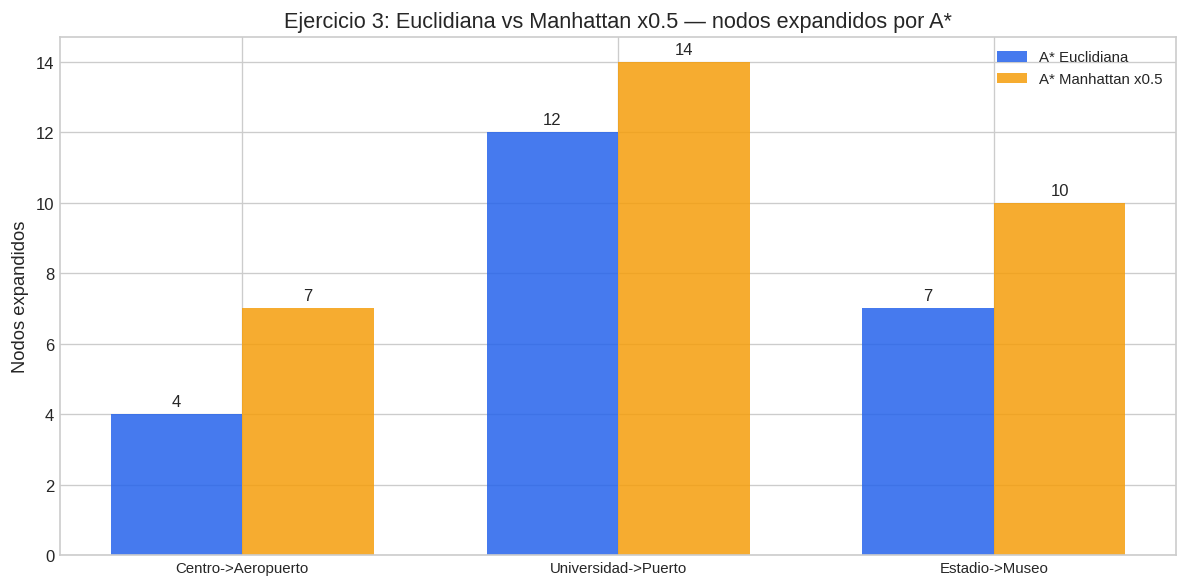


Conclusiones:
  Ambas heuristicas son ADMISIBLES: ningun nodo viola h(n) <= h*(n).
  La euclidiana es mas INFORMATIVA — mas ajustada al costo real
  -> expande menos nodos en todos los casos.
  La Manhattan x0.5 subestima mas (cota inferior menos ajustada)
  -> A* trabaja mas porque no puede descartar tantos nodos.
  Regla: entre dos heuristicas admisibles, la mas alta (mas informativa) es mejor.


In [14]:
# ── Ejercicio 3 ───────────────────────────────────────────────────────────────
# Tu código aquí

# Paso 1: Define la heurística Manhattan escalada
def heuristica_manhattan_escalada(nodo, meta):
    """
    h_manhattan(n) = 0.5 * (|x_n - x_meta| + |y_n - y_meta|)
    El factor 0.5 la hace admisible: la distancia Manhattan >= euclidiana,
    pero los pesos reales son distancias euclidianas, asi que escalamos
    para no sobreestimar.
    """
    xn, yn = POSICIONES[nodo]
    xm, ym = POSICIONES[meta]
    return 0.5 * (abs(xn - xm) + abs(yn - ym))


# Paso 2: Comparar en las 3 rutas de prueba
RUTAS_TEST = [
    ("Centro",      "Aeropuerto"),
    ("Universidad", "Puerto"),
    ("Estadio",     "Museo"),
]

print(f"{'Ruta':<30} {'Heuristica':<20} {'Expandidos':>11}  {'Costo':>7}")
print("-" * 72)
datos_barras = []
for origen, destino in RUTAS_TEST:
    for nombre_h, h_fn in [("Euclidiana", heuristica_euclidiana),
                            ("Manhattan x0.5", heuristica_manhattan_escalada)]:
        cam, costo, exp = a_star(GRAFO, origen, destino, h=h_fn)
        ruta_str = f"{origen} -> {destino}" if nombre_h == "Euclidiana" else ""
        print(f"{ruta_str:<30} {nombre_h:<20} {len(exp):>11}  {costo:>7.2f}")
        datos_barras.append((f"{origen}->{destino}", nombre_h, len(exp), costo))
    print()

# Paso 3: Verificar admisibilidad para todas las metas
print("Verificacion de admisibilidad — h(n) <= h*(n) para todo nodo n:")
print(f"{'Meta':<15} {'Viol. Euclidiana':>18} {'Viol. Manhattan':>17}")
print("-" * 52)
for meta in sorted(NODOS):
    dist_real, _, _ = dijkstra(GRAFO, meta)
    viol_e = sum(1 for n in NODOS if heuristica_euclidiana(n, meta) > dist_real[n] + 1e-9)
    viol_m = sum(1 for n in NODOS if heuristica_manhattan_escalada(n, meta) > dist_real[n] + 1e-9)
    print(f"{meta:<15} {'OK (0 viol.)' if viol_e==0 else str(viol_e)+' violaciones':>18} "
          f"{'OK (0 viol.)' if viol_m==0 else str(viol_m)+' violaciones':>17}")

# Visualizacion comparativa
rutas_uniq  = [f"{o}->{d}" for o, d in RUTAS_TEST]
exp_eucl    = [d[2] for d in datos_barras if d[1] == "Euclidiana"]
exp_manh    = [d[2] for d in datos_barras if d[1] == "Manhattan x0.5"]

x = np.arange(len(rutas_uniq))
ancho = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - ancho/2, exp_eucl, ancho, label='A* Euclidiana',     color=COLORS['primary'], alpha=0.85)
b2 = ax.bar(x + ancho/2, exp_manh, ancho, label='A* Manhattan x0.5', color=COLORS['accent'],  alpha=0.85)
ax.bar_label(b1, padding=3, fontsize=10)
ax.bar_label(b2, padding=3, fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(rutas_uniq, fontsize=9)
ax.set_ylabel('Nodos expandidos')
ax.set_title('Ejercicio 3: Euclidiana vs Manhattan x0.5 — nodos expandidos por A*')
ax.legend()
plt.tight_layout()
plt.show()

print()
print("Conclusiones:")
print("  Ambas heuristicas son ADMISIBLES: ningun nodo viola h(n) <= h*(n).")
print("  La euclidiana es mas INFORMATIVA — mas ajustada al costo real")
print("  -> expande menos nodos en todos los casos.")
print("  La Manhattan x0.5 subestima mas (cota inferior menos ajustada)")
print("  -> A* trabaja mas porque no puede descartar tantos nodos.")
print("  Regla: entre dos heuristicas admisibles, la mas alta (mas informativa) es mejor.")
